-> predict the total number of goals each team will score during the FIFA World Cup 2026.
-> predict the stage at which each team will finish the tournament (Group Stage, Round of 32, Round of 16, Quarter-finals, Semi-finals, Runner-up, or Champion).

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train_data = pd.read_csv("../data/raw/Train.csv")
test_data = pd.read_csv("../data/raw/Test.csv")

teams_data = pd.read_csv("../data/raw/data/teams.csv")
team_appearances_data = pd.read_csv("../data/raw/data/team_appearances.csv")
matches_data = pd.read_csv("../data/raw/data/matches.csv")
goals_data = pd.read_csv("../data/raw/data/goals.csv")
group_standings_data =pd.read_csv("../data/raw/data/group_standings.csv")
tournament_standings_data = pd.read_csv("../data/raw/data/tournament_standings.csv")

In [10]:
print(train_data.shape)
train_data.columns

(489, 12)


Index(['ID', 'team_id', 'country', 'team_code', 'confederation_name',
       'region_name', 'tournament_id', 'tournament_name', 'year',
       'matches_played', 'total_goals', 'stage_reached'],
      dtype='str')

In [11]:
print(test_data.shape)
test_data.columns

(48, 2)


Index(['ID', 'country'], dtype='str')

In [ ]:
print(teams_data.shape)
teams_data.columns

(88, 14)


Index(['key_id', 'team_id', 'team_name', 'team_code', 'mens_team',
       'womens_team', 'federation_name', 'region_name', 'confederation_id',
       'confederation_name', 'confederation_code', 'mens_team_wikipedia_link',
       'womens_team_wikipedia_link', 'federation_wikipedia_link'],
      dtype='str')

In [13]:
print(team_appearances_data.shape)
team_appearances_data.columns

(2496, 36)


Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'team_id', 'team_name', 'team_code',
       'opponent_id', 'opponent_name', 'opponent_code', 'home_team',
       'away_team', 'goals_for', 'goals_against', 'goal_differential',
       'extra_time', 'penalty_shootout', 'penalties_for', 'penalties_against',
       'result', 'win', 'lose', 'draw'],
      dtype='str')

In [14]:
print(matches_data.shape)
matches_data.columns

(1248, 37)


Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'home_team_id', 'home_team_name',
       'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code',
       'score', 'home_team_score', 'away_team_score', 'home_team_score_margin',
       'away_team_score_margin', 'extra_time', 'penalty_shootout',
       'score_penalties', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='str')

In [15]:
print(goals_data.shape)
goals_data.columns

(3637, 27)


Index(['key_id', 'goal_id', 'tournament_id', 'tournament_name', 'match_id',
       'match_name', 'match_date', 'stage_name', 'group_name', 'team_id',
       'team_name', 'team_code', 'home_team', 'away_team', 'player_id',
       'family_name', 'given_name', 'shirt_number', 'player_team_id',
       'player_team_name', 'player_team_code', 'minute_label',
       'minute_regulation', 'minute_stoppage', 'match_period', 'own_goal',
       'penalty'],
      dtype='str')

In [16]:
print(group_standings_data.shape)
group_standings_data.columns

(626, 19)


Index(['key_id', 'tournament_id', 'tournament_name', 'stage_number',
       'stage_name', 'group_name', 'position', 'team_id', 'team_name',
       'team_code', 'played', 'wins', 'draws', 'losses', 'goals_for',
       'goals_against', 'goal_difference', 'points', 'advanced'],
      dtype='str')

In [17]:
print(tournament_standings_data.shape)
tournament_standings_data.columns

(120, 7)


Index(['key_id', 'tournament_id', 'tournament_name', 'position', 'team_id',
       'team_name', 'team_code'],
      dtype='str')

In [18]:
inventory = {
    "train_data": train_data.shape,
    "test_data": test_data.shape,
    "teams_data": teams_data.shape,
    "team_appearances_data": team_appearances_data.shape,
    "matches_data": matches_data.shape,
    "goals_data": goals_data.shape,
    "group_standings_data": group_standings_data.shape,
    "tournament_standings_data": tournament_standings_data.shape
}

import pandas as pd

summary = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in inventory.items()],
    columns=["Dataset", "Rows", "Columns"]
)

summary

,Dataset,Rows,Columns
0,train_data,489,12
1,test_data,48,2
2,teams_data,88,14
3,team_appearances_data,2496,36
4,matches_data,1248,37
5,goals_data,3637,27
6,group_standings_data,626,19
7,tournament_standings_data,120,7


# Train.csv Schema Analysis

In [19]:
train_data.head()

,ID,team_id,country,team_code,confederation_name,region_name,tournament_id,tournament_name,year,matches_played,total_goals,stage_reached
0,WC-1930_ARG,T-03,Argentina,ARG,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,5,18,final
1,WC-1930_BEL,T-06,Belgium,BEL,Union of European Football Associations,Europe,WC-1930,1930 FIFA Men's World Cup,1930,2,0,group stage
2,WC-1930_BOL,T-07,Bolivia,BOL,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,2,0,group stage
3,WC-1930_BRA,T-09,Brazil,BRA,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,2,5,group stage
4,WC-1930_CHL,T-13,Chile,CHL,South American Football Confederation,South America,WC-1930,1930 FIFA Men's World Cup,1930,3,5,group stage


In [20]:
train_data.dtypes

ID                      str
team_id                 str
country                 str
team_code               str
confederation_name      str
region_name             str
tournament_id           str
tournament_name         str
year                  int64
matches_played        int64
total_goals           int64
stage_reached           str
dtype: object

In [22]:
train_data.isnull().sum()

ID                    0
team_id               0
country               0
team_code             0
confederation_name    0
region_name           0
tournament_id         0
tournament_name       0
year                  0
matches_played        0
total_goals           0
stage_reached         0
dtype: int64

In [23]:
train_data.duplicated().sum()

np.int64(0)

In [27]:
# Target Analysis

train_data['total_goals'].describe()

count    489.000000
mean       5.562372
std        4.530034
min        0.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       27.000000
Name: total_goals, dtype: float64

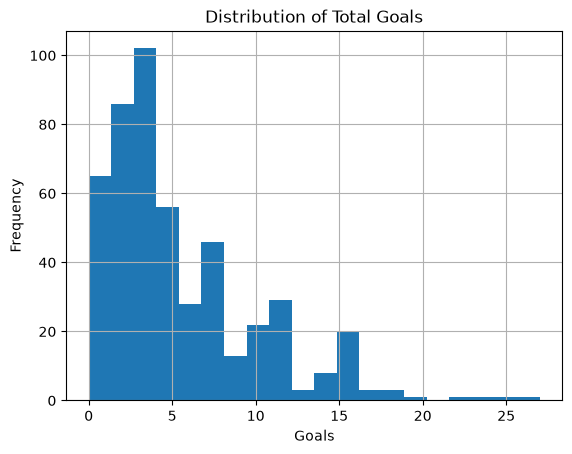

In [30]:
train_data['total_goals'].hist(bins=20)

plt.title("Distribution of Total Goals")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [31]:
train_data['stage_reached'].nunique()

8

In [32]:
train_data['stage_reached'].value_counts()

stage_reached
group stage           222
round of 16            95
quarter-finals         68
final                  42
third-place match      40
second group stage     16
final round             4
semi-finals             2
Name: count, dtype: int64

In [33]:
round(
    train_data['stage_reached'].value_counts(normalize=True)*100,
    2
)

stage_reached
group stage           45.40
round of 16           19.43
quarter-finals        13.91
final                  8.59
third-place match      8.18
second group stage     3.27
final round            0.82
semi-finals            0.41
Name: proportion, dtype: float64

In [35]:
# Team Analysis
train_data['country'].nunique()

85

In [36]:
train_data['country'].value_counts()

country
Brazil                    22
Argentina                 18
Italy                     18
Mexico                    17
France                    16
                          ..
Slovakia                   1
Bosnia and Herzegovina     1
Iceland                    1
Panama                     1
Qatar                      1
Name: count, Length: 85, dtype: int64

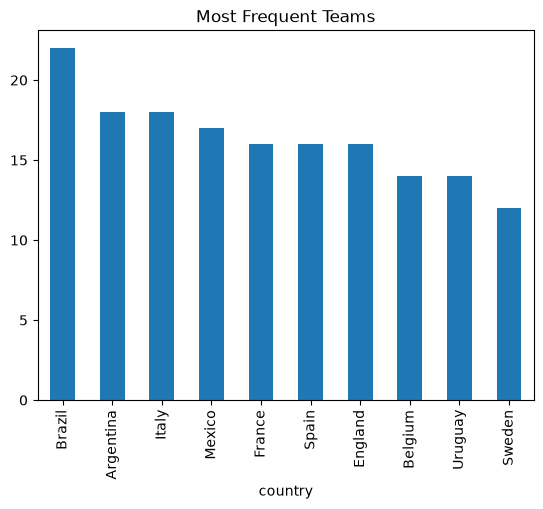

In [38]:
train_data['country'].value_counts().head(10).plot(kind='bar')

plt.title("Most Frequent Teams")
plt.show()

In [41]:
# Tournament Analysis

train_data['tournament_id'].nunique()

22

In [42]:
train_data['year'].min()

np.int64(1930)

In [43]:
train_data['year'].max()

np.int64(2022)

In [44]:
train_data['year'].value_counts().sort_index()

year
1930    13
1934    16
1938    15
1950    13
1954    16
1958    16
1962    16
1966    16
1970    16
1974    16
1978    16
1982    24
1986    24
1990    24
1994    24
1998    32
2002    32
2006    32
2010    32
2014    32
2018    32
2022    32
Name: count, dtype: int64

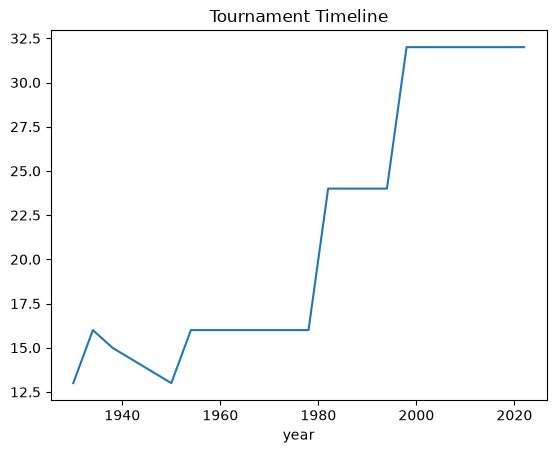

In [45]:
train_data['year'].value_counts().sort_index().plot()

plt.title("Tournament Timeline")
plt.show()

In [46]:
#Relationship Analysis

train_data.groupby('stage_reached')['total_goals'].mean().sort_values()

stage_reached
group stage            2.648649
round of 16            4.400000
semi-finals            7.000000
quarter-finals         7.176471
second group stage     7.250000
third-place match     11.800000
final                 13.476190
final round           14.500000
Name: total_goals, dtype: float64

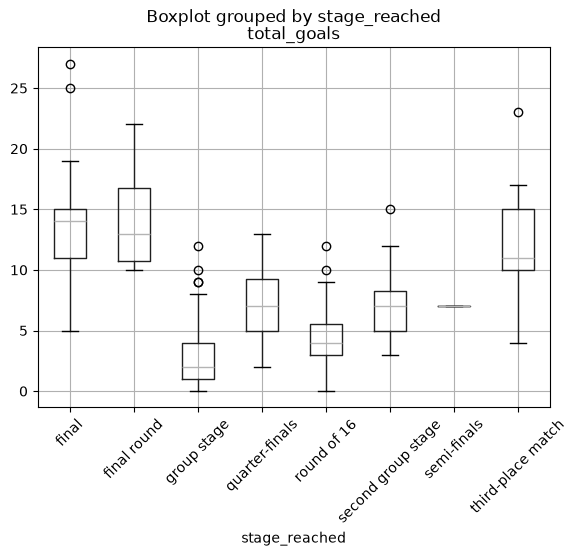

In [47]:
train_data.boxplot(
    column='total_goals',
    by='stage_reached',
    rot=45
)

plt.show()

In [48]:
train_data.groupby('stage_reached')['matches_played'].mean()

stage_reached
final                 6.357143
final round           5.250000
group stage           2.941441
quarter-finals        4.411765
round of 16           3.547368
second group stage    5.500000
semi-finals           3.000000
third-place match     6.400000
Name: matches_played, dtype: float64

In [50]:
numeric_cols = train_data.select_dtypes(include='number')

numeric_cols.corr()

,year,matches_played,total_goals
year,1.000000,0.212224,-0.086147
matches_played,0.212224,1.000000,0.747213
total_goals,-0.086147,0.747213,1.000000


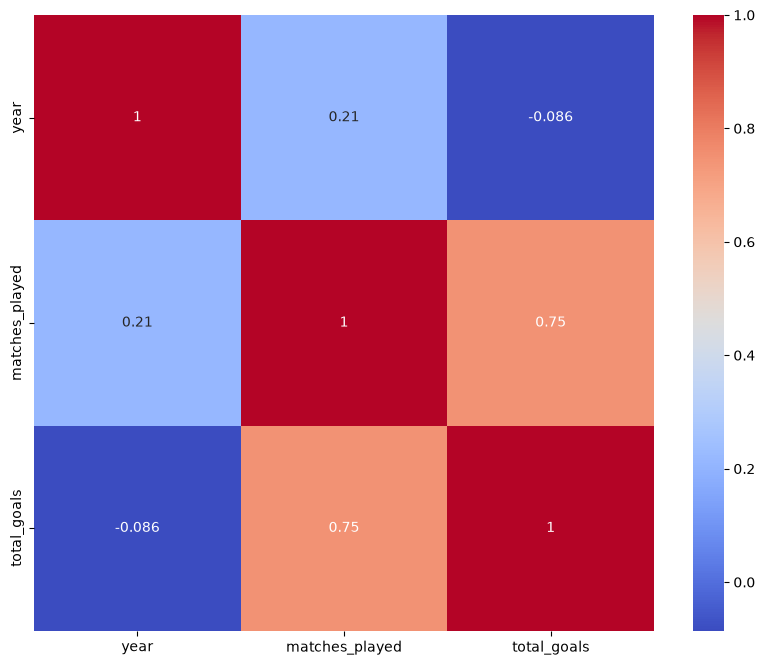

In [51]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()